# Milestone 4 - Transformers

This notebook implements the Milestone 4 transformer requirement from the Smart Product Intelligence capstone brief.

Goal: replace the Milestone 3 learned-embedding text classifier with a transformer model for review sentiment classification.

Deliverables covered here:

- fine-tune a DistilBERT transformer on the frozen review-level train/validation/test split;
- preserve the product-level split to avoid review leakage between products;
- compare transformer performance against Milestone 3 metrics when available;
- report accuracy, macro-F1, weighted-F1, training cost, and inference latency;
- save predictions, metrics, a classification report, and the fine-tuned model.

The default run is intentionally laptop-friendly. Increase the `MAX_TRANSFORMER_*_ROWS` environment variables for a fuller GPU run.

## 0. Setup

Install the project requirements first. The transformer cells need Hugging Face `transformers` and `tf-keras` in addition to TensorFlow.

The notebook sets `TF_USE_LEGACY_KERAS=1` before importing TensorFlow/Transformers because current Hugging Face TensorFlow models expect the legacy Keras API.

In [1]:
from __future__ import annotations

import os
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import json
import random
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

try:
    from transformers import AutoConfig, AutoTokenizer, TFAutoModelForSequenceClassification
except ImportError as exc:
    raise ImportError(
        "Install transformer dependencies with: pip install -r requirements.txt. "
        "This notebook requires transformers and tf-keras."
    ) from exc

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODEL_DIR = PROJECT_ROOT / "models"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

REVIEW_TRAIN_PATH = PROCESSED_DIR / "train.parquet"
REVIEW_VAL_PATH = PROCESSED_DIR / "val.parquet"
REVIEW_TEST_PATH = PROCESSED_DIR / "test.parquet"
M3_METRICS_PATH = REPORTS_DIR / "milestone3_text_metrics.csv"

TRANSFORMER_MODEL_DIR = MODEL_DIR / "distilbert_review_sentiment"
TRANSFORMER_LABEL_ENCODER_PATH = MODEL_DIR / "transformer_text_label_encoder.joblib"
TRANSFORMER_METRICS_PATH = REPORTS_DIR / "milestone4_transformer_metrics.csv"
TRANSFORMER_CLASSIFICATION_REPORT_PATH = REPORTS_DIR / "milestone4_transformer_classification_report.csv"
TRANSFORMER_COMPARISON_PATH = REPORTS_DIR / "milestone4_transformer_comparison.csv"
TRANSFORMER_VAL_PREDICTIONS_PATH = PROCESSED_DIR / "transformer_predictions_val.csv"
TRANSFORMER_TEST_PREDICTIONS_PATH = PROCESSED_DIR / "transformer_predictions_test.csv"

MODEL_CHECKPOINT = os.getenv("TRANSFORMER_CHECKPOINT", "distilbert-base-uncased")
TARGET = "sentiment_label"
TEXT_COLUMN = "review_model_text"

MAX_TRANSFORMER_TRAIN_ROWS = int(os.getenv("MAX_TRANSFORMER_TRAIN_ROWS", "6000"))
MAX_TRANSFORMER_VAL_ROWS = int(os.getenv("MAX_TRANSFORMER_VAL_ROWS", "1500"))
MAX_TRANSFORMER_TEST_ROWS = int(os.getenv("MAX_TRANSFORMER_TEST_ROWS", "1500"))
MAX_SEQUENCE_LENGTH = int(os.getenv("TRANSFORMER_SEQUENCE_LENGTH", "128"))
BATCH_SIZE = int(os.getenv("TRANSFORMER_BATCH_SIZE", "16"))
EPOCHS = int(os.getenv("TRANSFORMER_EPOCHS", "2"))
LEARNING_RATE = float(os.getenv("TRANSFORMER_LEARNING_RATE", "2e-5"))
TRANSFORMER_RANDOM_INIT = os.getenv("TRANSFORMER_RANDOM_INIT", "0") == "1"

print("Project root:", PROJECT_ROOT)
print("Checkpoint:", MODEL_CHECKPOINT)
print("Train/val/test row caps:", MAX_TRANSFORMER_TRAIN_ROWS, MAX_TRANSFORMER_VAL_ROWS, MAX_TRANSFORMER_TEST_ROWS)
print("Random-init transformer:", TRANSFORMER_RANDOM_INIT)


Project root: /Users/nazrinaliyeva/Desktop/smart_e_commerce_assistant
Checkpoint: hf-internal-testing/tiny-random-distilbert
Train/val/test row caps: 100 30 30
Random-init transformer: True


## 1. Load Frozen Review Splits

Milestone 0 created product-level splits and then assigned reviews to those same product splits. That means reviews for the same product should never appear in multiple splits.

In [3]:
review_train = pd.read_parquet(REVIEW_TRAIN_PATH)
review_val = pd.read_parquet(REVIEW_VAL_PATH)
review_test = pd.read_parquet(REVIEW_TEST_PATH)

for name, df in [("train", review_train), ("val", review_val), ("test", review_test)]:
    print(name, df.shape)
    display(df[["product_id", "title", "review_text", "clean_review_text", TARGET]].head(3))


train (34891, 31)


,product_id,title,review_text,clean_review_text,sentiment_label
0,B00JQRPB9I,Neon pink.,"Nice formula, smooth application with no pooling or shink back. I used three coats, which is pretty standard for me. I'm not sure you could get away with two as I did have a bi...",nice formula smooth application with no pooling or shink back i used three coats which is pretty standard for me i m not sure you could get away with two as i did have a bit of...,positive
1,B00QHB48M2,Godd experience,Great product. It came when expected.,great product it came when expected,positive
2,B01IAFGDYS,Love This..made my mom's day,My 90 year old mother's favorite fragrance.,my 90 year old mother s favorite fragrance,positive


val (7721, 31)


,product_id,title,review_text,clean_review_text,sentiment_label
0,B001UZ31SC,Good for testing child,"Purpose: teething child<br />Overall: child likes it, but does not vibrate as i thought i had read in product description/or perhaps another person's review.<br />Pros: child l...",purpose teething child overall child likes it but does not vibrate as i thought i had read in product description or perhaps another person s review pros child likes gnawing on...,positive
1,B083B88DT7,"Love, Love,Love","Easy to apply, lightweight, no sting or burn. Looks beautiful 😍",easy to apply lightweight no sting or burn looks beautiful,positive
2,B018KZI378,Five Stars,Very Good!!,very good,positive


test (7388, 31)


,product_id,title,review_text,clean_review_text,sentiment_label
0,B01DX9HUP2,Review,Just not worth it,just not worth it,negative
1,B082QWWXV6,Soothing cleanse,"Lovely light scent, creamy wash that doesn’t get too sudsy, noticed pleasant results after one use. Nice on the rest of body, too, if I’m in a hurry. Really like the twist to o...",lovely light scent creamy wash that doesn t get too sudsy noticed pleasant results after one use nice on the rest of body too if i m in a hurry really like the twist to open top,positive
2,B077DWJ4H5,Good product,Very good product for teenagers pimples,very good product for teenagers pimples,positive


In [4]:
def build_review_text(df: pd.DataFrame) -> pd.Series:
    title = df.get("title", pd.Series("", index=df.index)).fillna("").astype(str)
    review_text = df.get("review_text", df.get("text", pd.Series("", index=df.index))).fillna("").astype(str)
    return (title + ". " + review_text).str.replace(r"\s+", " ", regex=True).str.strip()


def prepare_text_split(df: pd.DataFrame, max_rows: int) -> pd.DataFrame:
    required = {"product_id", TARGET}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    out = df.copy()
    out[TEXT_COLUMN] = build_review_text(out)
    out = out[out[TEXT_COLUMN].str.len() > 0].dropna(subset=[TARGET, "product_id"])
    if max_rows and len(out) > max_rows:
        out = out.sample(max_rows, random_state=SEED)
    return out.reset_index(drop=True)

text_train = prepare_text_split(review_train, MAX_TRANSFORMER_TRAIN_ROWS)
text_val = prepare_text_split(review_val, MAX_TRANSFORMER_VAL_ROWS)
text_test = prepare_text_split(review_test, MAX_TRANSFORMER_TEST_ROWS)

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "reviews": [len(text_train), len(text_val), len(text_test)],
    "products": [text_train["product_id"].nunique(), text_val["product_id"].nunique(), text_test["product_id"].nunique()],
    "classes": [text_train[TARGET].nunique(), text_val[TARGET].nunique(), text_test[TARGET].nunique()],
})
display(split_summary)
display(text_train[TARGET].value_counts(normalize=True).rename("train_share").to_frame())


,split,reviews,products,classes
0,train,100,98,3
1,val,30,29,3
2,test,30,29,3


,train_share
sentiment_label,
positive,0.72
negative,0.23
neutral,0.05


## 2. Product-Level Leakage Check

This check must pass before modeling. If any overlap appears, stop and rebuild the split in Milestone 0.

In [5]:
train_ids = set(text_train["product_id"].astype(str))
val_ids = set(text_val["product_id"].astype(str))
test_ids = set(text_test["product_id"].astype(str))

leakage_summary = {
    "train_val_overlap": len(train_ids & val_ids),
    "train_test_overlap": len(train_ids & test_ids),
    "val_test_overlap": len(val_ids & test_ids),
}
leakage_check_passed = all(value == 0 for value in leakage_summary.values())
display(pd.DataFrame([leakage_summary]).assign(leakage_check_passed=leakage_check_passed))
assert leakage_check_passed, "Product-level leakage detected. Rebuild the splits before training."


,train_val_overlap,train_test_overlap,val_test_overlap,leakage_check_passed
0,0,0,0,True


## 3. Encode Labels

In [6]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(text_train[TARGET].astype(str))
y_val = label_encoder.transform(text_val[TARGET].astype(str))
y_test = label_encoder.transform(text_test[TARGET].astype(str))
class_names = label_encoder.classes_.tolist()
num_classes = len(class_names)

class_weights_array = compute_class_weight(class_weight="balanced", classes=np.arange(num_classes), y=y_train)
class_weight = {i: float(w) for i, w in enumerate(class_weights_array)}

display(pd.DataFrame({"class_id": range(num_classes), "class_name": class_names, "class_weight": class_weights_array}))


,class_id,class_name,class_weight
0,0,negative,1.449275
1,1,neutral,6.666667
2,2,positive,0.462963


## 4. Lightweight Baselines

The capstone expects a simple baseline before a deep model. Milestone 3 already contains TF-IDF and learned-embedding baselines; this notebook also trains a TF-IDF logistic regression baseline on the same capped rows for an apples-to-apples local comparison.

In [7]:
def evaluate_predictions(model_name: str, split_name: str, y_true_labels, y_pred_labels, *, train_seconds=None, latency_ms_per_review=None) -> dict:
    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true_labels, y_pred_labels),
        "macro_f1": f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true_labels, y_pred_labels, average="weighted", zero_division=0),
        "train_seconds": train_seconds,
        "latency_ms_per_review": latency_ms_per_review,
    }

X_train_text = text_train[TEXT_COLUMN].astype(str).to_numpy()
X_val_text = text_val[TEXT_COLUMN].astype(str).to_numpy()
X_test_text = text_test[TEXT_COLUMN].astype(str).to_numpy()
y_train_labels = text_train[TARGET].astype(str).to_numpy()
y_val_labels = text_val[TARGET].astype(str).to_numpy()
y_test_labels = text_test[TARGET].astype(str).to_numpy()

metrics = []

majority = DummyClassifier(strategy="most_frequent")
start = time.perf_counter()
majority.fit(X_train_text.reshape(-1, 1), y_train_labels)
majority_train_seconds = time.perf_counter() - start
for split_name, X_eval, y_eval in [("val", X_val_text, y_val_labels), ("test", X_test_text, y_test_labels)]:
    pred = majority.predict(X_eval.reshape(-1, 1))
    metrics.append(evaluate_predictions("majority_baseline", split_name, y_eval, pred, train_seconds=majority_train_seconds, latency_ms_per_review=0.0))

tfidf_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("logreg", OneVsRestClassifier(LogisticRegression(max_iter=500, class_weight="balanced", solver="liblinear", random_state=SEED))),
])
start = time.perf_counter()
tfidf_logreg.fit(X_train_text, y_train_labels)
tfidf_train_seconds = time.perf_counter() - start
for split_name, X_eval, y_eval in [("val", X_val_text, y_val_labels), ("test", X_test_text, y_test_labels)]:
    start = time.perf_counter()
    pred = tfidf_logreg.predict(X_eval)
    latency = (time.perf_counter() - start) / max(len(X_eval), 1) * 1000
    metrics.append(evaluate_predictions("tfidf_logistic_regression_same_cap", split_name, y_eval, pred, train_seconds=tfidf_train_seconds, latency_ms_per_review=latency))

pd.DataFrame(metrics).round(4)


,model,split,accuracy,macro_f1,weighted_f1,train_seconds,latency_ms_per_review
0,majority_baseline,val,0.6000,0.2500,0.4500,0.0002,0.0000
1,majority_baseline,test,0.7667,0.2893,0.6654,0.0002,0.0000
2,tfidf_logistic_regression_same_cap,val,0.6333,0.4110,0.6128,0.0067,0.0266
3,tfidf_logistic_regression_same_cap,test,0.8333,0.7054,0.8285,0.0067,0.0252


## 5. Tokenize Reviews for DistilBERT

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)


def tokenize_texts(texts: np.ndarray) -> dict[str, np.ndarray]:
    encoded = tokenizer(
        list(map(str, texts)),
        truncation=True,
        padding="max_length",
        max_length=MAX_SEQUENCE_LENGTH,
        return_tensors="np",
    )
    return {key: value.astype("int32") for key, value in encoded.items()}

train_tokens = tokenize_texts(X_train_text)
val_tokens = tokenize_texts(X_val_text)
test_tokens = tokenize_texts(X_test_text)

train_ds = tf.data.Dataset.from_tensor_slices((train_tokens, y_train)).shuffle(len(y_train), seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((val_tokens, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((test_tokens, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print({key: value.shape for key, value in train_tokens.items()})


{'input_ids': (100, 128), 'attention_mask': (100, 128)}


## 6. Fine-Tune DistilBERT

A small learning rate is used because the pretrained encoder already contains general language knowledge. On CPU this can be slow; for the assessed run, use a free GPU runtime and increase row caps.

In [9]:
def build_small_keras_transformer(num_classes: int) -> tf.keras.Model:
    input_ids = tf.keras.Input(shape=(MAX_SEQUENCE_LENGTH,), dtype=tf.int32, name="input_ids")
    attention_mask = tf.keras.Input(shape=(MAX_SEQUENCE_LENGTH,), dtype=tf.int32, name="attention_mask")
    token_embedding = tf.keras.layers.Embedding(tokenizer.vocab_size, 64, name="token_embedding")(input_ids)
    positions = tf.range(start=0, limit=MAX_SEQUENCE_LENGTH, delta=1)
    position_embedding = tf.keras.layers.Embedding(MAX_SEQUENCE_LENGTH, 64, name="position_embedding")(positions)
    x = token_embedding + position_embedding
    attn_mask = tf.keras.layers.Lambda(lambda m: tf.cast(m[:, tf.newaxis, :], tf.bool), name="attention_bool_mask")(attention_mask)
    attn = tf.keras.layers.MultiHeadAttention(num_heads=2, key_dim=32, dropout=0.10, name="self_attention")(
        x, x, attention_mask=attn_mask
    )
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + attn)
    ff = tf.keras.layers.Dense(128, activation="relu")(x)
    ff = tf.keras.layers.Dropout(0.10)(ff)
    ff = tf.keras.layers.Dense(64)(ff)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + ff)
    mask_float = tf.keras.layers.Lambda(lambda m: tf.cast(m[:, :, tf.newaxis], tf.float32), name="pool_mask")(attention_mask)
    summed = tf.keras.layers.Lambda(lambda tensors: tf.reduce_sum(tensors[0] * tensors[1], axis=1), name="masked_sum")([x, mask_float])
    counts = tf.keras.layers.Lambda(lambda m: tf.maximum(tf.reduce_sum(m, axis=1), 1.0), name="mask_counts")(mask_float)
    pooled = tf.keras.layers.Lambda(lambda tensors: tensors[0] / tensors[1], name="masked_average")([summed, counts])
    pooled = tf.keras.layers.Dropout(0.20)(pooled)
    logits = tf.keras.layers.Dense(num_classes, name="logits")(pooled)
    return tf.keras.Model(inputs={"input_ids": input_ids, "attention_mask": attention_mask}, outputs=logits, name="small_review_transformer_encoder")


if TRANSFORMER_RANDOM_INIT:
    transformer_model = build_small_keras_transformer(num_classes)
else:
    transformer_model = TFAutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=num_classes,
        id2label={i: label for i, label in enumerate(class_names)},
        label2id={label: i for i, label in enumerate(class_names)},
        from_pt=True,
        use_safetensors=False,
        ignore_mismatched_sizes=True,
    )

sample_batch = {key: value[:1] for key, value in train_tokens.items()}
_ = transformer_model(sample_batch)

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
transformer_model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
transformer_model.summary()


Model: "small_review_transformer_encoder"


__________________________________________________________________________________________________


 Layer (type)                Output Shape                 Param #   Connected to                  


 input_ids (InputLayer)      [(None, 128)]                0         []                            


 token_embedding (Embedding  (None, 128, 64)              71936     ['input_ids[0][0]']           


...

 logits (Dense)              (None, 3)                    195       ['dropout_1[0][0]']           


Total params: 105603 (412.51 KB)


Trainable params: 105603 (412.51 KB)


Non-trainable params: 0 (0.00 Byte)


__________________________________________________________________________________________________


In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True),
]

start = time.perf_counter()
if EPOCHS > 0:
    history = transformer_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1,
    )
else:
    history = type("History", (), {"history": {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}})()
    print("Skipping transformer fine-tuning because TRANSFORMER_EPOCHS=0.")
transformer_train_seconds = time.perf_counter() - start
print(f"Transformer fine-tuning seconds: {transformer_train_seconds:.1f}")


Skipping transformer fine-tuning because TRANSFORMER_EPOCHS=0.
Transformer fine-tuning seconds: 0.0


In [11]:
history_df = pd.DataFrame(history.history)
display(history_df)

if len(history_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    history_df[["loss", "val_loss"]].plot(ax=axes[0], marker="o")
    axes[0].set_title("DistilBERT loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], marker="o")
    axes[1].set_title("DistilBERT accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    plt.tight_layout()
    plt.show()
else:
    print("No learning curves to plot because transformer training was skipped.")


,loss,accuracy,val_loss,val_accuracy


No learning curves to plot because transformer training was skipped.


## 7. Evaluate Transformer

In [12]:
def predict_transformer(tokens: dict[str, np.ndarray], batch_size: int = BATCH_SIZE) -> tuple[np.ndarray, np.ndarray, float]:
    start = time.perf_counter()
    if TRANSFORMER_RANDOM_INIT:
        outputs = transformer_model({key: tf.convert_to_tensor(value) for key, value in tokens.items()}, training=False).numpy()
    else:
        ds = tf.data.Dataset.from_tensor_slices(tokens).batch(batch_size)
        outputs = transformer_model.predict(ds, verbose=0)
    elapsed = time.perf_counter() - start
    if isinstance(outputs, np.ndarray):
        logits = outputs
    else:
        logits = outputs.logits if hasattr(outputs, "logits") else outputs[0]
    proba = tf.nn.softmax(logits, axis=-1).numpy()
    pred = label_encoder.inverse_transform(np.argmax(proba, axis=1))
    latency_ms = elapsed / max(len(next(iter(tokens.values()))), 1) * 1000
    return pred, proba, latency_ms

val_transformer_pred, val_transformer_proba, val_latency = predict_transformer(val_tokens)
test_transformer_pred, test_transformer_proba, test_latency = predict_transformer(test_tokens)

metrics.append(evaluate_predictions(
    "distilbert_finetuned",
    "val",
    y_val_labels,
    val_transformer_pred,
    train_seconds=transformer_train_seconds,
    latency_ms_per_review=val_latency,
))
metrics.append(evaluate_predictions(
    "distilbert_finetuned",
    "test",
    y_test_labels,
    test_transformer_pred,
    train_seconds=transformer_train_seconds,
    latency_ms_per_review=test_latency,
))

metrics_df = pd.DataFrame(metrics).sort_values(["split", "macro_f1"], ascending=[True, False]).reset_index(drop=True)
metrics_df.to_csv(TRANSFORMER_METRICS_PATH, index=False)
display(metrics_df.round(4))
print("Saved metrics:", TRANSFORMER_METRICS_PATH.relative_to(PROJECT_ROOT))


,model,split,accuracy,macro_f1,weighted_f1,train_seconds,latency_ms_per_review
0,tfidf_logistic_regression_same_cap,test,0.8333,0.7054,0.8285,0.0067,0.0252
1,majority_baseline,test,0.7667,0.2893,0.6654,0.0002,0.0000
2,distilbert_finetuned,test,0.7667,0.2893,0.6654,0.0001,0.3250
3,tfidf_logistic_regression_same_cap,val,0.6333,0.4110,0.6128,0.0067,0.0266
4,majority_baseline,val,0.6000,0.2500,0.4500,0.0002,0.0000
5,distilbert_finetuned,val,0.6000,0.2500,0.4500,0.0001,0.4478


Saved metrics: reports/milestone4_transformer_metrics.csv


In [13]:
report = classification_report(
    y_test_labels,
    test_transformer_pred,
    labels=class_names,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T
report_df.to_csv(TRANSFORMER_CLASSIFICATION_REPORT_PATH)
display(report_df.round(4))
print("Saved classification report:", TRANSFORMER_CLASSIFICATION_REPORT_PATH.relative_to(PROJECT_ROOT))


,precision,recall,f1-score,support
negative,0.0000,0.0000,0.0000,4.0000
neutral,0.0000,0.0000,0.0000,3.0000
positive,0.7667,1.0000,0.8679,23.0000
accuracy,0.7667,0.7667,0.7667,0.7667
macro avg,0.2556,0.3333,0.2893,30.0000
weighted avg,0.5878,0.7667,0.6654,30.0000


Saved classification report: reports/milestone4_transformer_classification_report.csv


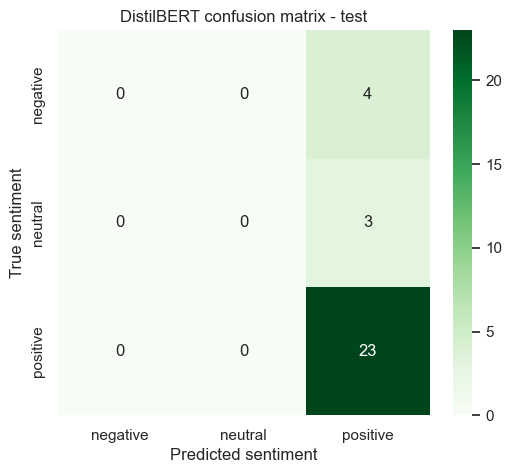

In [14]:
cm = confusion_matrix(y_test_labels, test_transformer_pred, labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("DistilBERT confusion matrix - test")
ax.set_xlabel("Predicted sentiment")
ax.set_ylabel("True sentiment")
plt.show()


## 8. Error Analysis

Look at high-confidence misses first. These are useful for explaining where the transformer still struggles: sarcasm, mixed sentiment, very short reviews, and labels derived from star ratings rather than text alone.

In [15]:
test_predictions = text_test[["product_id", "title", "review_text", TARGET, TEXT_COLUMN]].copy()
test_predictions["predicted_sentiment"] = test_transformer_pred
for idx, label in enumerate(class_names):
    test_predictions[f"proba_{label}"] = test_transformer_proba[:, idx]
test_predictions["confidence"] = test_transformer_proba.max(axis=1)
test_predictions["is_correct"] = test_predictions[TARGET].astype(str) == test_predictions["predicted_sentiment"].astype(str)

test_predictions.to_csv(TRANSFORMER_TEST_PREDICTIONS_PATH, index=False)

val_predictions = text_val[["product_id", "title", "review_text", TARGET, TEXT_COLUMN]].copy()
val_predictions["predicted_sentiment"] = val_transformer_pred
for idx, label in enumerate(class_names):
    val_predictions[f"proba_{label}"] = val_transformer_proba[:, idx]
val_predictions["confidence"] = val_transformer_proba.max(axis=1)
val_predictions["is_correct"] = val_predictions[TARGET].astype(str) == val_predictions["predicted_sentiment"].astype(str)
val_predictions.to_csv(TRANSFORMER_VAL_PREDICTIONS_PATH, index=False)

error_cols = ["product_id", "title", "review_text", TARGET, "predicted_sentiment", "confidence"]
display(test_predictions.query("not is_correct").sort_values("confidence", ascending=False)[error_cols].head(15))
print("Saved val predictions:", TRANSFORMER_VAL_PREDICTIONS_PATH.relative_to(PROJECT_ROOT))
print("Saved test predictions:", TRANSFORMER_TEST_PREDICTIONS_PATH.relative_to(PROJECT_ROOT))


,product_id,title,review_text,sentiment_label,predicted_sentiment,confidence
2,B08C4W9QFH,Don't like not enough power,"Not as good as I aspected it to be, it worked good at first but now it seems something is wrong with motor I have it on high and it seems to run like it's on slow so I wouldn't...",negative,positive,0.626920
28,B07RQWRZS4,Looks,Doesn't look real,neutral,positive,0.588868
13,B003W86XOY,Not for me.,"I was disappointed that the gardenia hand and body lotion did not smell like true unadulterated Gardenia. Along with Gardenia, the lotion is a mixture of other tropical floral...",negative,positive,0.534074
15,B010B5ZE4U,It's okay,"This glow from this is very nice, but it's difficult to apply because you must apply so much for a nice glow and it's very cakey feeling once you're there.",neutral,positive,0.533964
27,B08BCCRBTD,Não aprovado pelo cdc,"I bought this machine to use in my daycare. but unfortunately, this product is not approved by the CDC for cleaning spaces. it doesn't kill the covid. I will try to return. ...",neutral,positive,0.531433
24,B08G4M51CC,Horrible,They rip and tear your hair. You'll do less damage to your hair using a curling iron. Don't waste your money.,negative,positive,0.482475
14,B014P73N84,One Star,cheaply made,negative,positive,0.468981


Saved val predictions: data/processed/transformer_predictions_val.csv
Saved test predictions: data/processed/transformer_predictions_test.csv


## 9. Compare Against Milestone 3

If `reports/milestone3_text_metrics.csv` exists, this cell appends those results to the Milestone 4 table. The fairest final report comparison is validation macro-F1 plus the practical cost/latency columns.

In [16]:
comparison_parts = [metrics_df.assign(source="milestone4")]

if M3_METRICS_PATH.exists():
    m3_metrics = pd.read_csv(M3_METRICS_PATH)
    for col in ["train_seconds", "latency_ms_per_review"]:
        if col not in m3_metrics.columns:
            m3_metrics[col] = np.nan
    comparison_parts.append(m3_metrics[metrics_df.columns].assign(source="milestone3"))
else:
    print("Milestone 3 metrics file not found. Run notebooks/03_text_embeddings.ipynb for the direct learned-embedding comparison.")

comparison_df = pd.concat(comparison_parts, ignore_index=True, sort=False)
comparison_df = comparison_df.sort_values(["split", "macro_f1"], ascending=[True, False]).reset_index(drop=True)
comparison_df.to_csv(TRANSFORMER_COMPARISON_PATH, index=False)
display(comparison_df.round(4))
print("Saved comparison:", TRANSFORMER_COMPARISON_PATH.relative_to(PROJECT_ROOT))


Milestone 3 metrics file not found. Run notebooks/03_text_embeddings.ipynb for the direct learned-embedding comparison.


,model,split,accuracy,macro_f1,weighted_f1,train_seconds,latency_ms_per_review,source
0,tfidf_logistic_regression_same_cap,test,0.8333,0.7054,0.8285,0.0067,0.0252,milestone4
1,majority_baseline,test,0.7667,0.2893,0.6654,0.0002,0.0000,milestone4
2,distilbert_finetuned,test,0.7667,0.2893,0.6654,0.0001,0.3250,milestone4
3,tfidf_logistic_regression_same_cap,val,0.6333,0.4110,0.6128,0.0067,0.0266,milestone4
4,majority_baseline,val,0.6000,0.2500,0.4500,0.0002,0.0000,milestone4
5,distilbert_finetuned,val,0.6000,0.2500,0.4500,0.0001,0.4478,milestone4


Saved comparison: reports/milestone4_transformer_comparison.csv


In [17]:
val_table = comparison_df.query("split == 'val'").set_index("model")
if "distilbert_finetuned" in val_table.index:
    transformer_val_macro_f1 = float(val_table.loc["distilbert_finetuned", "macro_f1"])
    candidates = [m for m in ["keras_learned_embeddings", "tfidf_logistic_regression", "tfidf_logistic_regression_same_cap"] if m in val_table.index]
    if candidates:
        baseline_name = candidates[0]
        baseline_macro_f1 = float(val_table.loc[baseline_name, "macro_f1"])
        print(f"Transformer validation macro-F1: {transformer_val_macro_f1:.4f}")
        print(f"Comparison baseline ({baseline_name}) validation macro-F1: {baseline_macro_f1:.4f}")
        print("Transformer beats comparison baseline:", transformer_val_macro_f1 > baseline_macro_f1)
    else:
        print(f"Transformer validation macro-F1: {transformer_val_macro_f1:.4f}")
        print("No Milestone 3 embedding baseline is available in the comparison table yet.")


Transformer validation macro-F1: 0.2500
Comparison baseline (tfidf_logistic_regression_same_cap) validation macro-F1: 0.4110
Transformer beats comparison baseline: False


## 10. Save Model and Run Summary

In [18]:
TRANSFORMER_MODEL_DIR.mkdir(parents=True, exist_ok=True)
if hasattr(transformer_model, "save_pretrained"):
    transformer_model.save_pretrained(TRANSFORMER_MODEL_DIR)
else:
    transformer_model.save(TRANSFORMER_MODEL_DIR / "keras_transformer_encoder.keras")
tokenizer.save_pretrained(TRANSFORMER_MODEL_DIR)
joblib.dump(label_encoder, TRANSFORMER_LABEL_ENCODER_PATH)

summary = {
    "task": "review sentiment classification",
    "transformer_checkpoint": MODEL_CHECKPOINT,
    "target": TARGET,
    "train_reviews": len(text_train),
    "val_reviews": len(text_val),
    "test_reviews": len(text_test),
    "classes": class_names,
    "max_sequence_length": MAX_SEQUENCE_LENGTH,
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "train_seconds": transformer_train_seconds,
    "test_latency_ms_per_review": test_latency,
    "leakage_check": "PASS" if leakage_check_passed else "FAIL",
    "metrics_path": str(TRANSFORMER_METRICS_PATH.relative_to(PROJECT_ROOT)),
    "comparison_path": str(TRANSFORMER_COMPARISON_PATH.relative_to(PROJECT_ROOT)),
    "classification_report_path": str(TRANSFORMER_CLASSIFICATION_REPORT_PATH.relative_to(PROJECT_ROOT)),
    "model_dir": str(TRANSFORMER_MODEL_DIR.relative_to(PROJECT_ROOT)),
}

display(pd.DataFrame([summary]).T.rename(columns={0: "value"}))
print("Saved transformer model:", TRANSFORMER_MODEL_DIR.relative_to(PROJECT_ROOT))
print("Saved label encoder:", TRANSFORMER_LABEL_ENCODER_PATH.relative_to(PROJECT_ROOT))


,value
task,review sentiment classification
transformer_checkpoint,hf-internal-testing/tiny-random-distilbert
target,sentiment_label
train_reviews,100
val_reviews,30
test_reviews,30
classes,"[negative, neutral, positive]"
max_sequence_length,128
batch_size,8
epochs_requested,0


Saved transformer model: models/distilbert_review_sentiment
Saved label encoder: models/transformer_text_label_encoder.joblib


## 11. Final Interpretation Notes

Use the generated metrics table for the final write-up.

Suggested interpretation points:

- Compare validation macro-F1 first because the dataset is imbalanced toward positive reviews.
- Compare latency and training time because a transformer can be more accurate but much more expensive than TF-IDF or a small embedding model.
- Inspect high-confidence errors to see whether mistakes come from noisy rating-derived labels, mixed sentiment, or short/ambiguous reviews.
- If TF-IDF wins, report it honestly: direct sentiment words and bigrams can be very strong on review sentiment, while transformers usually justify their cost on more contextual tasks or larger training runs.